# Comparison Pipeline

This notebook compares semaglutide and sertraline using both the full filtered tables and the high-quality tables (`source_count >= 2`).

## Step 0. Load comparison inputs

Set `DATA_DIR` to the folder containing the CSV files. Leave it as `""` if the files are in the current working directory.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA_DIR = ""

FILES = {
    "semaglutide_filtered": "semaglutide_final_results_filtered_table.csv",
    "sertraline_filtered": "sertraline_final_results_filtered_table.csv",
    "semaglutide_high_quality": "semaglutide_high_quality_table.csv",
    "sertraline_high_quality": "sertraline_high_quality_table.csv",
}

def load_csv(name):
    path = os.path.join(DATA_DIR, FILES[name])
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path)

semaglutide_df = load_csv("semaglutide_filtered")
sertraline_df = load_csv("sertraline_filtered")
semaglutide_hq_df = load_csv("semaglutide_high_quality")
sertraline_hq_df = load_csv("sertraline_high_quality")

print("Loaded files successfully.")
print("Semaglutide filtered rows:", len(semaglutide_df))
print("Sertraline filtered rows:", len(sertraline_df))
print("Semaglutide high-quality rows:", len(semaglutide_hq_df))
print("Sertraline high-quality rows:", len(sertraline_hq_df))

Loaded files successfully.
Semaglutide filtered rows: 827
Sertraline filtered rows: 389
Semaglutide high-quality rows: 38
Sertraline high-quality rows: 32


## Step 1. Compare filtered full tables

In [3]:
def summarize_table(df, drug_name):
    return {
        "drug": drug_name,
        "agreement_score": round((df["source_count"] >= 2).mean(), 3),
        "divergence_score": round((df["source_count"] == 1).mean(), 3),
        "total_terms": len(df),
        "high_support_terms": int((df["source_count"] >= 3).sum()),
    }

summary_df = pd.DataFrame([
    summarize_table(semaglutide_df, "semaglutide"),
    summarize_table(sertraline_df, "sertraline"),
])

display(summary_df)
summary_df.to_csv(os.path.join(DATA_DIR, "comparison_summary.csv"), index=False)
print("Saved: comparison_summary.csv")

,drug,agreement_score,divergence_score,total_terms,high_support_terms
0,semaglutide,0.046,0.954,827,12
1,sertraline,0.082,0.918,389,9


Saved: comparison_summary.csv


## Step 2. Compare high-support terms

In [4]:
semaglutide_high = set(semaglutide_df[semaglutide_df["source_count"] >= 3]["term"])
sertraline_high = set(sertraline_df[sertraline_df["source_count"] >= 3]["term"])

shared_high_terms = sorted(semaglutide_high & sertraline_high)
semaglutide_only_high = sorted(semaglutide_high - sertraline_high)
sertraline_only_high = sorted(sertraline_high - semaglutide_high)

print("Shared highly supported terms:")
print(shared_high_terms if shared_high_terms else "None")

print("\nSemaglutide-only highly supported terms:")
print(semaglutide_only_high if semaglutide_only_high else "None")

print("\nSertraline-only highly supported terms:")
print(sertraline_only_high if sertraline_only_high else "None")

Shared highly supported terms:
['dizziness', 'fatigue', 'headache', 'vomiting']

Semaglutide-only highly supported terms:
['abdominal distension', 'abdominal pain', 'abdominal pain upper', 'constipation', 'diarrhea', 'dyspepsia', 'pancreatitis', 'weight loss']

Sertraline-only highly supported terms:
['anxiety', 'drowsiness', 'insomnia', 'nausea', 'tremor']


## Step 3. Full-table comparison charts

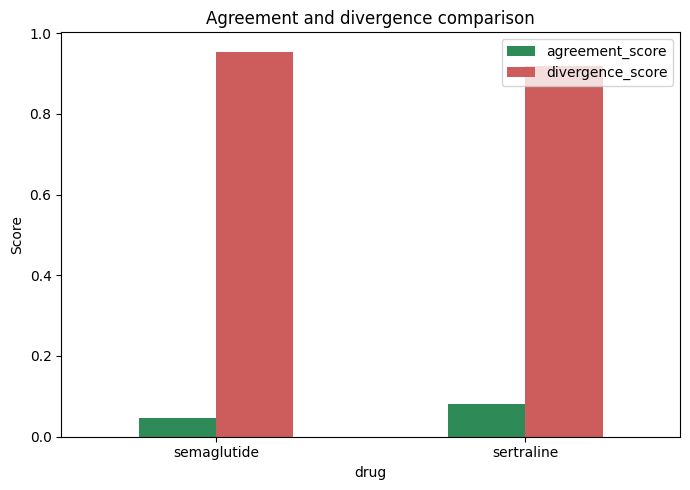

Source-count distribution:


,semaglutide,sertraline
source_count,,
1,789.0,357
2,26.0,23
3,12.0,6
4,0.0,3


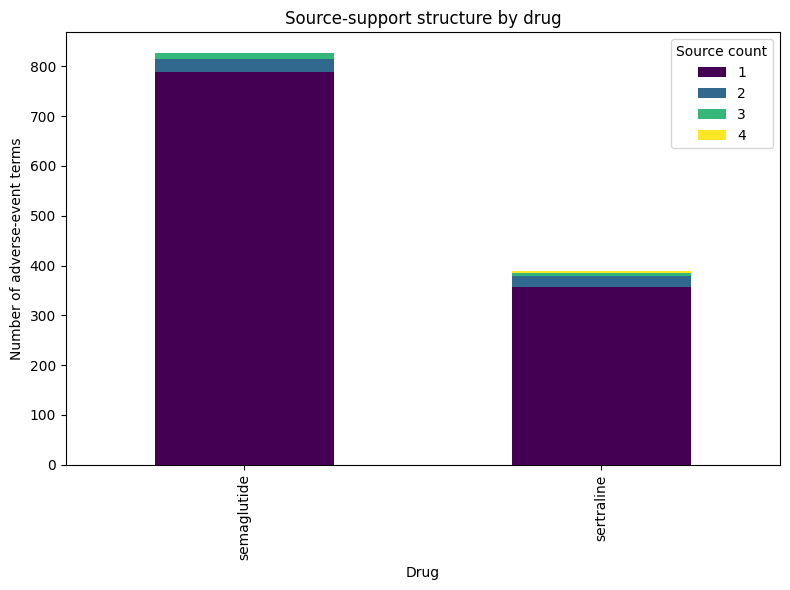

In [5]:
plot_df = summary_df.set_index("drug")[["agreement_score", "divergence_score"]]
plot_df.plot(kind="bar", figsize=(7, 5), color=["seagreen", "indianred"])
plt.title("Agreement and divergence comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

semi_support = semaglutide_df["source_count"].value_counts().sort_index()
sert_support = sertraline_df["source_count"].value_counts().sort_index()
support_compare = pd.DataFrame({
    "semaglutide": semi_support,
    "sertraline": sert_support,
}).fillna(0)

print("Source-count distribution:")
display(support_compare)

support_compare.T.plot(kind="bar", stacked=True, figsize=(8, 6), colormap="viridis")
plt.title("Source-support structure by drug")
plt.xlabel("Drug")
plt.ylabel("Number of adverse-event terms")
plt.legend(title="Source count")
plt.tight_layout()
plt.show()

## Step 4. Side-by-side top FAERS terms

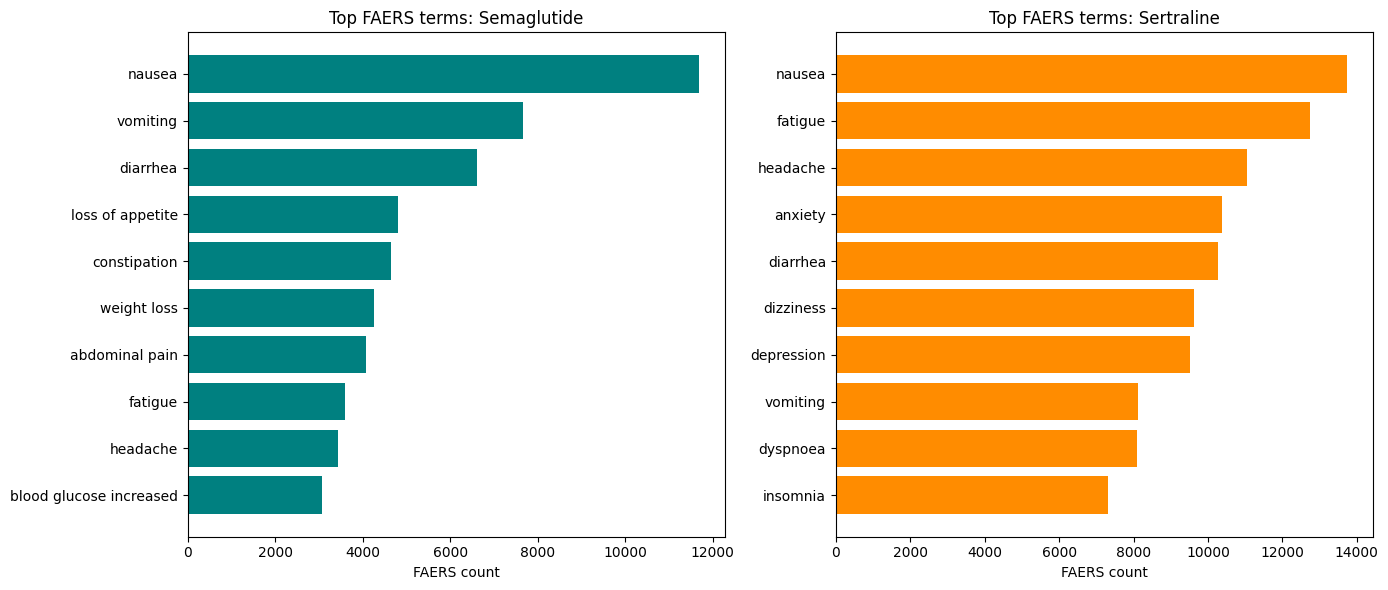

Top semaglutide terms:


,term,faers_count,in_faers,in_dailymed,in_clinicaltrials,in_pubmed,source_count
12,nausea,11688,True,False,True,False,2
0,vomiting,7662,True,True,True,False,3
1,diarrhea,6617,True,True,True,False,3
13,loss of appetite,4817,True,False,True,False,2
2,constipation,4658,True,True,True,False,3
3,weight loss,4257,True,False,True,True,3
4,abdominal pain,4068,True,True,True,False,3
5,fatigue,3589,True,True,True,False,3
6,headache,3442,True,True,True,False,3
14,blood glucose increased,3069,True,False,True,False,2


Top sertraline terms:


,term,faers_count,in_faers,in_dailymed,in_clinicaltrials,in_pubmed,source_count
0,nausea,13740,True,True,True,True,4
3,fatigue,12742,True,True,True,False,3
4,headache,11061,True,True,True,False,3
1,anxiety,10377,True,True,True,True,4
9,diarrhea,10271,True,False,True,False,2
5,dizziness,9622,True,True,True,False,3
10,depression,9531,True,False,False,True,2
6,vomiting,8120,True,True,True,False,3
32,dyspnoea,8082,True,False,False,False,1
2,insomnia,7308,True,True,True,True,4


In [6]:
semi_top = semaglutide_df.sort_values("faers_count", ascending=False).head(10)
sert_top = sertraline_df.sort_values("faers_count", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(semi_top["term"][::-1], semi_top["faers_count"][::-1], color="teal")
axes[0].set_title("Top FAERS terms: Semaglutide")
axes[0].set_xlabel("FAERS count")

axes[1].barh(sert_top["term"][::-1], sert_top["faers_count"][::-1], color="darkorange")
axes[1].set_title("Top FAERS terms: Sertraline")
axes[1].set_xlabel("FAERS count")

plt.tight_layout()
plt.show()

print("Top semaglutide terms:")
display(semi_top)
print("Top sertraline terms:")
display(sert_top)

## Step 5. Presence heatmap for selected terms

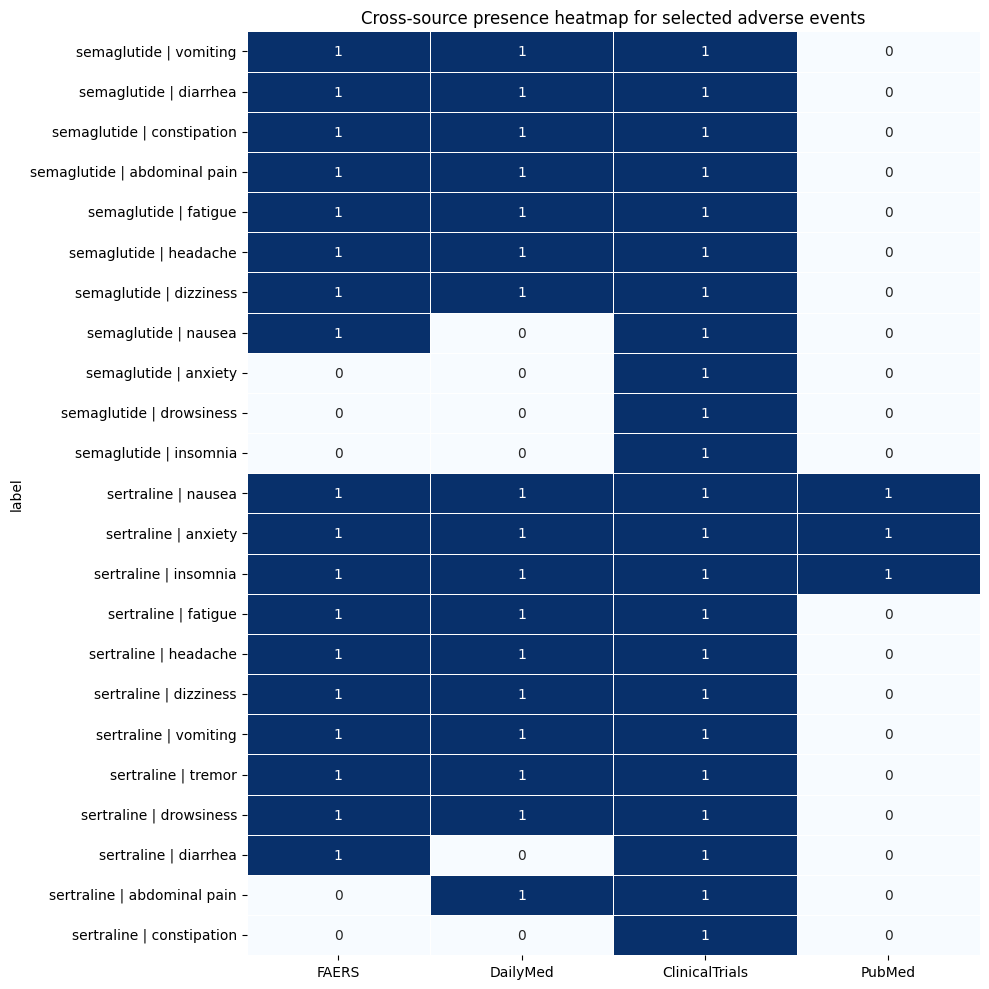

In [7]:
selected_terms = [
    "nausea", "vomiting", "diarrhea", "constipation", "abdominal pain",
    "fatigue", "headache", "dizziness", "anxiety", "insomnia", "tremor", "drowsiness"
]

def build_presence(df, drug_name):
    sub = df[df["term"].isin(selected_terms)].copy()
    sub["drug"] = drug_name
    return sub

combined = pd.concat([
    build_presence(semaglutide_df, "semaglutide"),
    build_presence(sertraline_df, "sertraline"),
], ignore_index=True)

heatmap_rows = []
for _, row in combined.iterrows():
    heatmap_rows.append({
        "label": f"{row['drug']} | {row['term']}",
        "FAERS": int(row["in_faers"]),
        "DailyMed": int(row["in_dailymed"]),
        "ClinicalTrials": int(row["in_clinicaltrials"]),
        "PubMed": int(row["in_pubmed"]),
    })

heatmap_df = pd.DataFrame(heatmap_rows).set_index("label")

plt.figure(figsize=(10, 10))
sns.heatmap(heatmap_df, annot=True, cmap="Blues", cbar=False, linewidths=0.5)
plt.title("Cross-source presence heatmap for selected adverse events")
plt.tight_layout()
plt.show()

## Step 6. High-quality table comparison

This focuses only on terms supported by at least two sources.

In [8]:
hq_summary_df = pd.DataFrame([
    summarize_table(semaglutide_hq_df, "semaglutide_high_quality"),
    summarize_table(sertraline_hq_df, "sertraline_high_quality"),
])

display(hq_summary_df)

print("Semaglutide high-quality table:")
display(semaglutide_hq_df.head(20))

print("Sertraline high-quality table:")
display(sertraline_hq_df.head(20))

,drug,agreement_score,divergence_score,total_terms,high_support_terms
0,semaglutide_high_quality,1.0,0.0,38,12
1,sertraline_high_quality,1.0,0.0,32,9


Semaglutide high-quality table:


,term,faers_count,in_faers,in_dailymed,in_clinicaltrials,in_pubmed,source_count
0,vomiting,7662,True,True,True,False,3
1,diarrhea,6617,True,True,True,False,3
2,constipation,4658,True,True,True,False,3
3,weight loss,4257,True,False,True,True,3
4,abdominal pain,4068,True,True,True,False,3
5,fatigue,3589,True,True,True,False,3
6,headache,3442,True,True,True,False,3
7,abdominal pain upper,2965,True,True,True,False,3
8,dizziness,2898,True,True,True,False,3
9,dyspepsia,1694,True,True,True,False,3


Sertraline high-quality table:


,term,faers_count,in_faers,in_dailymed,in_clinicaltrials,in_pubmed,source_count
0,nausea,13740,True,True,True,True,4
1,anxiety,10377,True,True,True,True,4
2,insomnia,7308,True,True,True,True,4
3,fatigue,12742,True,True,True,False,3
4,headache,11061,True,True,True,False,3
5,dizziness,9622,True,True,True,False,3
6,vomiting,8120,True,True,True,False,3
7,tremor,5500,True,True,True,False,3
8,drowsiness,5390,True,True,True,False,3
9,diarrhea,10271,True,False,True,False,2


## Step 7. Final interpretation

In [9]:
semi_agreement = summary_df.loc[summary_df["drug"] == "semaglutide", "agreement_score"].values[0]
sert_agreement = summary_df.loc[summary_df["drug"] == "sertraline", "agreement_score"].values[0]
semi_divergence = summary_df.loc[summary_df["drug"] == "semaglutide", "divergence_score"].values[0]
sert_divergence = summary_df.loc[summary_df["drug"] == "sertraline", "divergence_score"].values[0]

print("Comparative interpretation:")
if semi_agreement > sert_agreement:
    print("- Semaglutide shows slightly higher cross-source agreement than sertraline.")
elif sert_agreement > semi_agreement:
    print("- Sertraline shows slightly higher cross-source agreement than semaglutide.")
else:
    print("- Both drugs show similar agreement.")

if semi_divergence > sert_divergence:
    print("- Semaglutide shows greater divergence than sertraline.")
elif sert_divergence > semi_divergence:
    print("- Sertraline shows greater divergence than semaglutide.")
else:
    print("- Both drugs show similar divergence.")

if shared_high_terms:
    print("- Shared highly supported terms:", ", ".join(shared_high_terms))
else:
    print("- No highly supported terms were shared across both drugs at the current threshold.")

if semaglutide_only_high:
    print("- Semaglutide retained distinct highly supported gastrointestinal-type terms.")
if sertraline_only_high:
    print("- Sertraline retained distinct highly supported neuropsychiatric-type terms.")

Comparative interpretation:
- Sertraline shows slightly higher cross-source agreement than semaglutide.
- Semaglutide shows greater divergence than sertraline.
- Shared highly supported terms: dizziness, fatigue, headache, vomiting
- Semaglutide retained distinct highly supported gastrointestinal-type terms.
- Sertraline retained distinct highly supported neuropsychiatric-type terms.
